In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats

In [ ]:
df = pd.read_csv('json_test.csv')

In [17]:
df = pd.read_csv("TestSegments\DoubleBump1.csv")

In [18]:
df['time'] = pd.to_datetime(df['time'])

In [ ]:
# MLR coefficients
MODEL_CONSTANT = 0.3761
MODEL_SPEED_COEF = 0.4139
MODEL_ACC_X_COEF = 1.1229

In [ ]:
# speed coefficients
MODEL_CONSTANT = 3.7115
MODEL_SPEED_COEF = 0.9729
MODEL_ACC_X_COEF = 0

In [ ]:
ROLLING_RANGE = 25

ACC_X_OFFSET = -0.7152996666441955 # Used to account for apparent sensor offset
ACC_Z_OFFSET = 9.8 # To account for gravity

ERROR_THRESHOLD = 4.653

REPEATED_POI_PREVENTION_THRESHOLD = 40

In [29]:
import time


rolling_abs_acc_z = []
rolling_abs_acc_x = []

entries_since_POI = REPEATED_POI_PREVENTION_THRESHOLD

elapsed_time_tracking = []

for i in range(len(df)):
    start_time = time.time()
    imu_point = df.iloc[i]

    rolling_abs_acc_z.append(abs(imu_point['acc_z']  - ACC_Z_OFFSET))
    if len(rolling_abs_acc_z) > ROLLING_RANGE:
        del rolling_abs_acc_z[0]

    rolling_abs_acc_x.append(abs(imu_point['acc_x']  - ACC_X_OFFSET))
    if (len(rolling_abs_acc_x) > ROLLING_RANGE):
        del rolling_abs_acc_x[0]

    acc_z_normalized_rolling_magnitude = np.mean(rolling_abs_acc_z)
    acc_x_normalized_rolling_magnitude = np.mean(rolling_abs_acc_x)

    acc_z_pred = MODEL_CONSTANT + (acc_x_normalized_rolling_magnitude * MODEL_ACC_X_COEF) + (imu_point['speed'] * MODEL_SPEED_COEF)

    absolute_error = abs(acc_z_normalized_rolling_magnitude - acc_z_pred)

    is_potential_POI = absolute_error > ERROR_THRESHOLD

    if (is_potential_POI):
        if entries_since_POI < REPEATED_POI_PREVENTION_THRESHOLD:
            is_potential_POI = False
        entries_since_POI = 0
    else:
        entries_since_POI += 1

    df.at[i, 'POI'] = is_potential_POI
    end_time = time.time()

    elapsed_time = end_time - start_time
    elapsed_time_tracking.append(elapsed_time)

    if i % 10000 == 0:
        print(f"Iteration: {i} / {len(df)}   Average time per iteration: {np.mean(elapsed_time_tracking)}")
print(f"Average time per iteration: {np.mean(elapsed_time_tracking)}")

    

Iteration: 0 / 2985   Average time per iteration: 0.0009968280792236328
Average time per iteration: 0.00029299279153846216


In [30]:
df['POI'].describe()

count      2985
unique        2
top       False
freq       2983
Name: POI, dtype: object

<Axes: xlabel='time', ylabel='speed'>

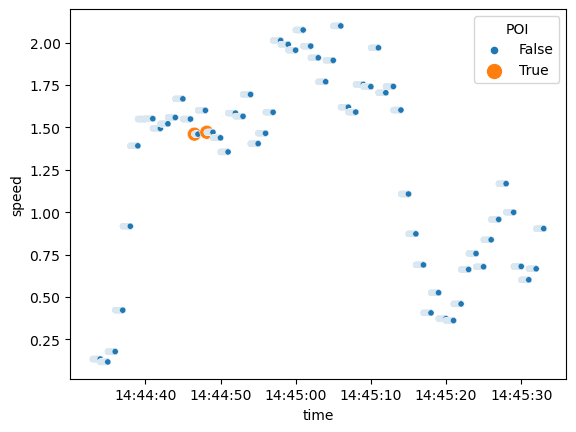

In [22]:
dot_sizes = {True: 100, False: 20}
sns.scatterplot(data=df, x='time', y='speed', hue='POI', size='POI', sizes=dot_sizes)